# LangGraph Streaming - 七种观察窗

这个 notebook 参照文章版示例，把 `updates`、`values`、`messages`、`custom`、`tasks`、`checkpoints`、`debug` 放到同一张图上横向对比。

重点不是单独看 token 流，而是把 streaming 当成 runtime 的多路观测接口来理解。

## 七种观察窗

| 观察窗 | stream mode | 你会看到什么 | 它更像在回答什么问题 |
|---|---|---|---|
| 状态增量 | `updates` | 每个节点刚刚写入了什么 | 谁改了什么？ |
| 状态快照 | `values` | 每一步之后的完整 state | 全局状态现在长什么样？ |
| 模型输出 | `messages` | LLM 的 token / message chunk 和 metadata | 模型此刻在输出什么？来自哪个节点？ |
| 业务事件 | `custom` | 节点通过 `get_stream_writer()` 主动发出的任意数据 | 这一步想对外汇报什么进度？ |
| 运行时任务 | `tasks` | task 的开始、结束、结果和错误 | 现在跑到哪了？有没有失败？ |
| 保存点 | `checkpoints` | checkpoint 创建时的完整快照 | 什么时候形成了可恢复的保存点？ |
| 深度调试 | `debug` | 比 `tasks` / `checkpoints` 更完整的 runtime 事件 | runtime 当时到底看到了什么？ |

下面统一使用 `version="v2"`。这样每条事件都遵循同一个外层结构：`{"type": ..., "ns": (), "data": ...}`。

## Setup

建议使用 `langgraph-deepseek` 内核。缺依赖时，可取消下一格的注释后执行安装。

这个 notebook 不会写死 API key。运行模型相关 cell 之前，请先在环境变量里设置 `DEEPSEEK_API_KEY`。

In [3]:
# %pip install -U langgraph langchain langchain-openai pydantic

In [4]:
import os
import uuid
from pprint import pprint

from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.config import get_stream_writer
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

In [ ]:
os.environ.setdefault("DEEPSEEK_BASE_URL", "https://api.deepseek.com")
os.environ.setdefault("DEEPSEEK_MODEL", "deepseek-chat")
os.environ["DEEPSEEK_API_KEY"] = "sk-43fd8b3b130f439e8c43b6e4361c8ec6"

if "DEEPSEEK_API_KEY" not in os.environ:
    raise ValueError(
        "DEEPSEEK_API_KEY is not set. Run your API-key setup cell first, "
        "or export it before running this notebook."
    )

model = ChatOpenAI(
    model=os.environ["DEEPSEEK_MODEL"],
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url=os.environ["DEEPSEEK_BASE_URL"],
    temperature=0,
    streaming=True,
)

ValueError: DEEPSEEK_API_KEY is not set. Run your API-key setup cell first, or export it before running this notebook.

## Graph 定义

这张图故意很小，但同时覆盖三类信号：

- 节点 state 写入：用于看 `updates` 和 `values`
- DeepSeek 模型调用：用于看 `messages`
- 节点主动发出的进度事件：用于看 `custom`

另外图会挂上 `InMemorySaver()`，这样 `tasks`、`checkpoints` 和 `debug` 也能一起观察。

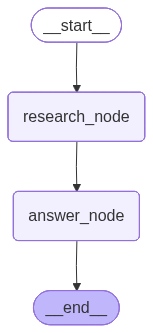

In [ ]:
class State(TypedDict):
    topic: str
    research: str
    answer: str


def research_node(state: State):
    writer = get_stream_writer()
    writer({"progress": "搜索资料中...", "pct": 30})
    result = model.invoke(
        [
            {
                "role": "user",
                "content": f"用一句话介绍 {state['topic']} 的核心概念",
            }
        ]
    )
    writer({"progress": "资料整理完成", "pct": 60})
    return {"research": result.content}


def answer_node(state: State):
    writer = get_stream_writer()
    writer({"progress": "生成回答中...", "pct": 85})
    result = model.invoke(
        [
            {
                "role": "user",
                "content": (
                    f"基于这个背景：{state['research']}，\n"
                    "写一段简洁解释给初学者"
                ),
            }
        ]
    )
    return {"answer": result.content}


builder = StateGraph(State)
builder.add_node("research_node", research_node)
builder.add_node("answer_node", answer_node)
builder.add_edge(START, "research_node")
builder.add_edge("research_node", "answer_node")
builder.add_edge("answer_node", END)
graph = builder.compile(checkpointer=InMemorySaver())


def make_stream_config(label: str):
    return {
        "configurable": {
            "thread_id": f"streaming-v2-{label}-{uuid.uuid4().hex[:8]}"
        }
    }


def extract_message_text(message_chunk):
    text_value = getattr(message_chunk, "text", "")
    if callable(text_value):
        text_value = text_value()
    if text_value:
        return text_value

    content = getattr(message_chunk, "content", "")
    if isinstance(content, str):
        return content

    if isinstance(content, list):
        text_parts = []
        for item in content:
            if isinstance(item, str):
                text_parts.append(item)
            elif isinstance(item, dict) and "text" in item:
                text_parts.append(str(item["text"]))
        return "".join(text_parts)

    return str(content) if content else ""


inputs = {"topic": "量子计算"}
display(Image(graph.get_graph().draw_mermaid_png()))

## 各 `stream_mode` 示例

下面每个 cell 都重新跑同一张图，只是把 `stream_mode` 换成不同值。这样可以直接横向比较各自暴露的 runtime 信息层次。

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("updates"),
    stream_mode="updates",
    version="v2",
):
    if chunk["type"] == "updates":
        for node, delta in chunk["data"].items():
            print(f"[{node}] 写入: {list(delta.keys())}")

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("values"),
    stream_mode="values",
    version="v2",
):
    if chunk["type"] == "values":
        state_snapshot = chunk["data"]
        print(
            f"topic={state_snapshot['topic']!r} "
            f"research={'✓' if state_snapshot.get('research') else '—'} "
            f"answer={'✓' if state_snapshot.get('answer') else '—'}"
        )

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("messages"),
    stream_mode="messages",
    version="v2",
):
    if chunk["type"] == "messages":
        message_chunk, metadata = chunk["data"]
        text = extract_message_text(message_chunk)
        if text:
            print(text, end="", flush=True)

print()

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("custom"),
    stream_mode="custom",
    version="v2",
):
    if chunk["type"] == "custom":
        data = chunk["data"]
        print(f"[{data['pct']}%] {data['progress']}")

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("tasks"),
    stream_mode="tasks",
    version="v2",
):
    if chunk["type"] == "tasks":
        task = chunk["data"]
        phase = "start" if "triggers" in task else "finish"
        print(
            f"task={task['name']!r} phase={phase} "
            f"error={task.get('error')} "
            f"has_result={'result' in task}"
        )

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("checkpoints"),
    stream_mode="checkpoints",
    version="v2",
):
    if chunk["type"] == "checkpoints":
        checkpoint = chunk["data"]
        print(
            f"checkpoint: step={checkpoint['metadata'].get('step')} "
            f"keys={list(checkpoint['values'].keys())}"
        )

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("debug"),
    stream_mode="debug",
    version="v2",
):
    if chunk["type"] == "debug":
        envelope = chunk["data"]
        print(envelope['type'], envelope.get('payload', {}).get('name', ''))

## 同时订阅多种模式

生产里更常见的写法是把多个观察窗接到一个统一消费者上，再通过 `chunk["type"]` 做分发。

In [ ]:
for chunk in graph.stream(
    inputs,
    make_stream_config("multi"),
    stream_mode=["updates", "messages", "custom", "tasks"],
    version="v2",
):
    event_type = chunk["type"]

    if event_type == "custom":
        data = chunk["data"]
        print(f"\r[{data['pct']:3d}%] {data['progress']}", end="", flush=True)

    elif event_type == "messages":
        message_chunk, metadata = chunk["data"]
        text = extract_message_text(message_chunk)
        if text:
            print(text, end="", flush=True)

    elif event_type == "updates":
        for node, delta in chunk["data"].items():
            print(f"\n✓ {node} 完成，写入字段: {list(delta.keys())}")

    elif event_type == "tasks":
        task = chunk["data"]
        if task.get("error"):
            print(f"\n✗ {task['name']} 出错: {task['error']}")

官方文档：

- https://langchain-ai.github.io/langgraph/how-tos/streaming/
- https://docs.langchain.com/oss/python/langgraph/streaming